# 03 — Is the scoring tool itself accurate?

**Why:** notebook 02 said the metric is partly real. This notebook asks whether the tool measuring it (Macro-Etym) actually agrees with hand-annotated truth — and whether it's adding anything over 50-year-old readability metrics.

**Two checks (§2 tool accuracy, §3 convergent validity), one verdict (§4).**

## 1. Setup

Same corpus paths as notebooks 01 and 02. One HTTP call to download EtymoLink (~5k rows).

In [1]:
import sys
import io
import subprocess
import tempfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests

print("Python", sys.version.split()[0])
print("pandas", pd.__version__)
print("numpy", np.__version__)

DATA_DIR = (Path.cwd() / ".." / "data" / "babylm_2026" / "strict_small").resolve()
MACROETYM_BIN = str(Path(sys.executable).parent / "macroetym")  # resolve in the venv, not via PATH

SOURCE_ORDER = [
    "switchboard",
    "bnc_spoken",
    "childes",
    "open_subtitles",
    "simple_wiki",
    "gutenberg",
]
source_paths = {s: DATA_DIR / f"{s}.train.txt" for s in SOURCE_ORDER}
for s, p in source_paths.items():
    assert p.exists(), f"missing corpus file: {p}. Run notebook 01 first."


def macroetym_single_word(word: str) -> str:
    """Return Macro-Etym's family verdict for one word: 'Latinate', 'Germanic', or 'other'.

    Macro-Etym is file-oriented and reports family percentages. For a single word
    we expect one family at 100%. If nothing recognised, return 'other'.
    """
    with tempfile.NamedTemporaryFile(suffix=".txt", mode="w", delete=False) as f:
        f.write(word)
        tmp_path = f.name
    try:
        out = subprocess.run(
            [MACROETYM_BIN, tmp_path],
            capture_output=True, text=True, check=True,
        ).stdout
    finally:
        Path(tmp_path).unlink(missing_ok=True)
    family = {}
    for line in out.splitlines():
        parts = line.split()
        if len(parts) >= 2:
            try:
                family[parts[0]] = float(parts[-1])
            except ValueError:
                continue
    if not family:
        return "other"
    top = max(family.items(), key=lambda kv: kv[1])
    if top[0] in ("Latinate", "Germanic"):
        return top[0]
    return "other"


print("Setup OK.")

Python 3.13.13
pandas 3.0.3
numpy 2.4.6
Setup OK.


## 2. Macro-Etym vs EtymoLink (gold standard)

**Why:** Macro-Etym has never been benchmarked. Bar-Ilan & Berman hand-counted; we use a tool. We need to know how often the tool agrees with truth before we trust it at corpus scale.

**How:**
1. EtymoLink has ~5.3k English words, each hand-labelled with origin language. Parse its `sorted` column (e.g. *commence* → `(commence_E, OF);(OF, L)` means English from Old French from Latin). Take the immediate ancestor.
2. Bucket into Germanic vs Latinate by language code. ~1,684 words pass this filter.
3. Sample 300 of each class (balanced).
4. Ask Macro-Etym for each word's verdict. Confusion matrix → precision / recall / F1 per class.

**Read the F1 numbers:**
- ≥ 0.85 → cite confidently
- 0.65–0.85 → honest middle, caveat in methods section
- < 0.65 → flag to TA

In [2]:
# Step 1: download EtymoLink and inspect schema.
ETYMOLINK_URL = "https://raw.githubusercontent.com/yuan-w-gao/etymolink/main/annotated_formatted.csv"

resp = requests.get(ETYMOLINK_URL, timeout=30)
resp.raise_for_status()
etymolink = pd.read_csv(io.StringIO(resp.text))

print(f"EtymoLink: {len(etymolink):,} rows × {len(etymolink.columns)} columns")
print("Columns:", etymolink.columns.tolist())
print("\nFirst rows:")
print(etymolink.head(10).to_string())

EtymoLink: 5,361 rows × 4 columns
Columns: ['sorted', 'word', 'full text', 'candidates']

First rows:
                                                                                                                       sorted          word                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                       

In [3]:
import re

# EtymoLink encodes etymology chains in the `sorted` column. Format:
#   (word_E, ancestor_LANG);(ancestor_LANG, deeper_LANG);...
# The first tuple's second element is the immediate ancestor — its language code
# tells us where the word came from. We collapse those codes to two buckets that
# match Macro-Etym's families (Germanic vs Latinate).

GERMANIC_CODES = {
    "OE",      # Old English
    "PGer",    # Proto-Germanic
    "WGer", "PWGer",  # West Germanic
    "Ger", "ModG", "HGer", "OHGer", "LGer", "GE",  # German lineage
    "ONor",    # Old Norse
    "Dut", "ODut", "ADut", "Du",  # Dutch
    "OFri",    # Old Frisian
    "Scan",    # Scandinavian
    "Dan", "ODan",  # Danish
    "Swe",     # Swedish
    "Norw", "Nor",  # Norwegian
    "Flem",    # Flemish
    "Go",      # Gothic
    "Frank",   # Frankish
    "pgER",    # likely typo for PGer
}
LATINATE_CODES = {
    "L", "OL", "VL", "LateL", "MediL", "ModL", "ChuL", "preL", "EL", "AL",  # Latin lineage
    "F", "OF", "MF", "AF", "ONF", "AngF", "Fran", "FCan", "LF",  # French lineage
    "I",       # Italian
    "Span", "ASpan", "MexSpan", "CuSpan",  # Spanish
    "Port", "Por",  # Portuguese
    "Cata",    # Catalan
    "Pro", "OPro",  # Provençal
    "Ro",      # Romance / Romanian
    "GaRo",    # Gallo-Romance
    "Gas",     # Gascon
}

FIRST_TUPLE_RE = re.compile(r"\(\s*([^,_]+)_(\w+)\s*,\s*([^,_)]+)_(\w+)\s*\)")


def immediate_origin(sorted_chain: str) -> str | None:
    """Return the immediate-ancestor language code from EtymoLink's first tuple, or None."""
    if not isinstance(sorted_chain, str):
        return None
    m = FIRST_TUPLE_RE.search(sorted_chain)
    if not m:
        return None
    _, head_lang, _, ancestor_lang = m.groups()
    # The first tuple should be (word_E, ancestor_LANG). If not, bail.
    if head_lang != "E":
        return None
    return ancestor_lang


def bucket(code: str | None) -> str | None:
    if code is None:
        return None
    if code in GERMANIC_CODES:
        return "Germanic"
    if code in LATINATE_CODES:
        return "Latinate"
    return None  # Greek, Arabic, PIE, href, etc. — excluded from binary calibration.


tidy = etymolink[["word", "sorted"]].copy()
tidy["origin_code"] = tidy["sorted"].map(immediate_origin)
tidy["truth"] = tidy["origin_code"].map(bucket)
tidy["word"] = tidy["word"].astype(str).str.lower().str.strip()

# Transparency: how many rows were dropped, and why?
n_total = len(tidy)
n_no_origin = tidy["origin_code"].isna().sum()
n_other_lang = (tidy["origin_code"].notna() & tidy["truth"].isna()).sum()
print(f"Drop breakdown (transparency):")
print(f"  total EtymoLink rows                                : {n_total}")
print(f"  dropped — no parseable first-tuple origin            : {n_no_origin}")
print(f"  dropped — origin language outside Germanic/Latinate  : {n_other_lang}")
print(f"  kept                                                 : {n_total - n_no_origin - n_other_lang}")
print()

# Show what we dropped as "other" so the bucketing is auditable.
other_codes = tidy.loc[tidy["origin_code"].notna() & tidy["truth"].isna(), "origin_code"].value_counts().head(15)
print(f"Top 15 'other' codes excluded from binary calibration:")
print(other_codes)
print()

tidy = tidy.dropna(subset=["truth"]).drop_duplicates(subset=["word"])

print("Origin-code coverage (top 15 codes that mapped to a bucket):")
print(tidy["origin_code"].value_counts().head(15))
print()
print("Truth-label distribution (collapsed to two buckets):")
print(tidy["truth"].value_counts())
print(f"\nTotal calibration-eligible words: {len(tidy)}")
print(f"Natural class proportions in the eligible population: "
      f"{(tidy['truth'] == 'Latinate').mean():.1%} Latinate, "
      f"{(tidy['truth'] == 'Germanic').mean():.1%} Germanic")

Drop breakdown (transparency):
  total EtymoLink rows                                : 5361
  dropped — no parseable first-tuple origin            : 2384
  dropped — origin language outside Germanic/Latinate  : 1281
  kept                                                 : 1696

Top 15 'other' codes excluded from binary calibration:
origin_code
E       896
G       144
href     57
H        21
Arab     13
San      12
Jap      11
Yid       8
Ch        8
Tur       7
Scot      7
Hin       7
Ir        7
e         5
PIE       5
Name: count, dtype: int64

Origin-code coverage (top 15 codes that mapped to a bucket):
origin_code
L        375
F        345
OF       297
OE       227
AF        65
Ger       63
LateL     61
MediL     58
I         46
ModL      24
ONor      23
Dut       22
Span      21
PGer       6
LGer       6
Name: count, dtype: int64

Truth-label distribution (collapsed to two buckets):
truth
Latinate    1319
Germanic     365
Name: count, dtype: int64

Total calibration-eligible words

In [4]:
# Step 3: balanced random sample.
SAMPLE_PER_CLASS = 300
RNG = np.random.default_rng(seed=42)

per_class = []
for cls in ["Latinate", "Germanic"]:
    pool = tidy[tidy["truth"] == cls]
    n = min(SAMPLE_PER_CLASS, len(pool))
    per_class.append(pool.sample(n=n, random_state=RNG.integers(0, 2**32 - 1)))
sample = pd.concat(per_class).reset_index(drop=True)
print(f"Calibration sample: {len(sample)} words ({sample['truth'].value_counts().to_dict()})")

Calibration sample: 600 words ({'Latinate': 300, 'Germanic': 300})


In [5]:
# Step 4: ask Macro-Etym for each word's verdict. ~1s per call, ~10 min for 600 words.
predictions = []
for i, word in enumerate(sample["word"]):
    pred = macroetym_single_word(word)
    predictions.append(pred)
    if (i + 1) % 50 == 0:
        print(f"  {i + 1}/{len(sample)}")
sample["pred"] = predictions

print("\nPrediction distribution:")
print(sample["pred"].value_counts())

  50/600


  100/600


  150/600


  200/600


  250/600


...

  400/600


  450/600


  500/600


  550/600


  600/600

Prediction distribution:
pred
Germanic    450
Latinate    139
other        11
Name: count, dtype: int64


In [6]:
# Step 5: confusion matrix and precision/recall/F1 per class.
# 'other' predictions = Macro-Etym didn't recognise the word. We report them as a coverage stat
# but exclude them from precision/recall (no prediction to compare against).

coverage = (sample["pred"] != "other").mean()
print(f"Macro-Etym coverage on the calibration sample: {coverage:.1%}")

scored = sample[sample["pred"] != "other"]
print(f"Words used for precision/recall: {len(scored)}")

confusion = pd.crosstab(scored["truth"], scored["pred"],
                        rownames=["truth (EtymoLink)"],
                        colnames=["pred (Macro-Etym)"])
for cls in ("Latinate", "Germanic"):
    if cls not in confusion.columns:
        confusion[cls] = 0
    if cls not in confusion.index:
        confusion.loc[cls] = 0
confusion = confusion[["Latinate", "Germanic"]].reindex(["Latinate", "Germanic"])
print("\nConfusion matrix:")
print(confusion)

rows = []
for cls in ("Latinate", "Germanic"):
    tp = confusion.loc[cls, cls]
    fp = confusion[cls].sum() - tp
    fn = confusion.loc[cls].sum() - tp
    precision = tp / (tp + fp) if (tp + fp) else float("nan")
    recall = tp / (tp + fn) if (tp + fn) else float("nan")
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else float("nan")
    rows.append({"class": cls, "precision": precision, "recall": recall, "f1": f1,
                 "support": int(confusion.loc[cls].sum())})
scores = pd.DataFrame(rows).set_index("class")
print("\nPer-class precision / recall / F1 (computed on the BALANCED 300/300 sample):")
print(scores.round(3))

# IMPORTANT: per-class precision/recall are not affected by the 50/50 resampling,
# but the macro-average F1 below treats the two classes equally — whereas the
# real EtymoLink-eligible population is 78% Latinate / 22% Germanic. A
# population-weighted average is a more honest "what would happen at corpus scale".
nat_lat = (tidy["truth"] == "Latinate").mean()
nat_ger = 1 - nat_lat
macro_f1 = scores["f1"].mean()
weighted_f1 = nat_lat * scores.loc["Latinate", "f1"] + nat_ger * scores.loc["Germanic", "f1"]
print(f"\nMacro-average F1 (equal weight, balanced sample):    {macro_f1:.3f}")
print(f"Population-weighted F1 ({nat_lat:.0%} Latinate prior): {weighted_f1:.3f}")
print(f"  (the natural distribution tilts toward Latinate F1 = {scores.loc['Latinate', 'f1']:.3f},\n"
      f"   so corpus-scale agreement is closer to the weighted number.)")

print(f"\nHEADLINE: Macro-Etym vs EtymoLink — "
      f"Latinate F1 = {scores.loc['Latinate', 'f1']:.3f}, "
      f"Germanic F1 = {scores.loc['Germanic', 'f1']:.3f}, "
      f"coverage = {coverage:.1%}")

Macro-Etym coverage on the calibration sample: 98.2%
Words used for precision/recall: 589

Confusion matrix:
pred (Macro-Etym)  Latinate  Germanic
truth (EtymoLink)                    
Latinate                128       165
Germanic                 11       285

Per-class precision / recall / F1 (computed on the BALANCED 300/300 sample):
          precision  recall     f1  support
class                                      
Latinate      0.921   0.437  0.593      293
Germanic      0.633   0.963  0.764      296

Macro-average F1 (equal weight, balanced sample):    0.678
Population-weighted F1 (78% Latinate prior): 0.630
  (the natural distribution tilts toward Latinate F1 = 0.593,
   so corpus-scale agreement is closer to the weighted number.)

HEADLINE: Macro-Etym vs EtymoLink — Latinate F1 = 0.593, Germanic F1 = 0.764, coverage = 98.2%


**Result:** Latinate F1 = **0.59**, Germanic F1 = **0.76**, coverage 98%. Population-weighted F1 = **0.63** (corpus-scale estimate, since the natural class split is 78% Latinate / 22% Germanic). Below the 0.65 threshold on Latinate.

**Implication:** Macro-Etym has a **strong Germanic-leaning bias**. Latinate recall is only 0.44 — it misses more than half of true Latinate words. So all corpus-level Latinate ratios in notebook 01 are **systematic under-estimates**. Two ways to fix before any training experiment:

1. **Hybrid scorer** — use EtymoLink directly for the 1.7k words it covers (high precision); Macro-Etym for the rest.
2. **Bias correction** — apply confusion-matrix-derived per-source correction factors to Macro-Etym output. Cheap, defensible.

**Caveat:** we call Macro-Etym one word at a time (subprocess per word). The tool is designed for prose / word lists; single-word mode *might* take a different lookup path internally. A quick 10-word batch-vs-single-mode comparison would settle this — flagged for next iteration.

## 3. Convergent validity — readability metrics (Flesch-Kincaid, Gunning Fog, Coleman-Liau)

**Why:** decades-old readability tools (1940s–70s) measure "how hard is this to read?" using word length and sentence length. If our fancy-ratio moves tightly with them, we're not measuring something new — we're rediscovering reading difficulty with an etymology pipeline bolted on top.

**How:** per source, compute Flesch-Kincaid + Gunning Fog + Coleman-Liau on the same 200k-char slice we score for fancy-ratio. Pearson r between fancy-ratio and each.

**Heads-up:** Coleman-Liau is purely character-based, so a high r there is the length confound from notebook 02 §3 (r=0.87 with word length) reappearing — not independent evidence.

**Read the r values:** > 0.9 = same axis as readability tools; 0.5–0.9 = partial overlap; < 0.5 = genuinely new axis.

All metrics computed on the same 200k-char slice of each source:
                latinate_ratio  flesch_kincaid  gunning_fog  coleman_liau
source                                                                   
switchboard              0.581           6.226        8.722         3.239
bnc_spoken               0.664           9.843       12.298         7.856
childes                  0.383           0.991        3.007         1.138
open_subtitles           0.556           3.056        4.798         4.209
simple_wiki              0.678           9.857       11.988        10.772
gutenberg                0.531           6.065        8.216         6.977

Pairwise Pearson correlation (n = 6 sources):
                latinate_ratio  flesch_kincaid  gunning_fog  coleman_liau
latinate_ratio           1.000           0.921        0.908         0.827
flesch_kincaid           0.921           1.000        0.998         0.877
gunning_fog              0.908           0.998        1.000         0.850


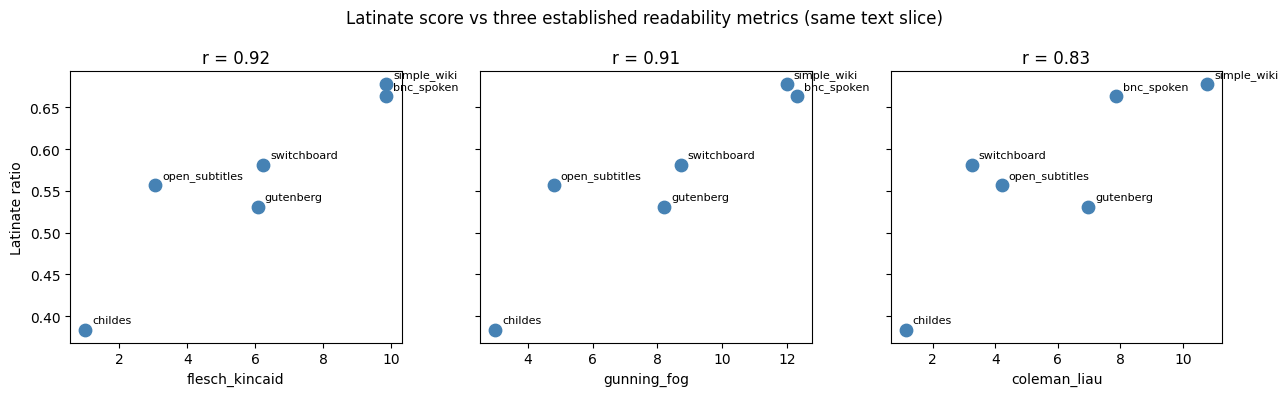

In [7]:
import textstat

# Use the SAME text slice for both sides of every correlation: read 200k chars
# per source, write that slice to a tempfile, run macroetym on the tempfile for
# the Latinate ratio, and feed the same string to textstat for the readability
# metrics. Previous version computed the Latinate ratio on the full file and
# readability on a 200k-char slice — a measurement-level mismatch the reviewer
# (correctly) called out.

SAMPLE_CHARS = 200_000


def macroetym_ratio_for_text(text: str) -> float:
    with tempfile.NamedTemporaryFile(suffix=".txt", mode="w", delete=False) as f:
        f.write(text)
        tmp_path = f.name
    try:
        out = subprocess.run([MACROETYM_BIN, tmp_path],
                             capture_output=True, text=True, check=True).stdout
    finally:
        Path(tmp_path).unlink(missing_ok=True)
    family = {}
    for line in out.splitlines():
        parts = line.split()
        if len(parts) >= 2:
            try:
                family[parts[0]] = float(parts[-1])
            except ValueError:
                continue
    lat = family.get("Latinate", 0.0)
    ger = family.get("Germanic", 0.0)
    return lat / (lat + ger) if (lat + ger) > 0 else float("nan")


rows = []
for source in SOURCE_ORDER:
    text = source_paths[source].read_text(encoding="utf-8")[:SAMPLE_CHARS]
    rows.append({
        "source": source,
        "latinate_ratio": macroetym_ratio_for_text(text),
        "flesch_kincaid": textstat.flesch_kincaid_grade(text),
        "gunning_fog": textstat.gunning_fog(text),
        "coleman_liau": textstat.coleman_liau_index(text),
    })

rd = pd.DataFrame(rows).set_index("source").loc[SOURCE_ORDER]
print("All metrics computed on the same 200k-char slice of each source:")
print(rd.round(3))

corr = rd.corr(method="pearson")
print("\nPairwise Pearson correlation (n = 6 sources):")
print(corr.round(3))

fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)
for ax, col in zip(axes, ["flesch_kincaid", "gunning_fog", "coleman_liau"]):
    ax.scatter(rd[col], rd["latinate_ratio"], s=80, color="steelblue", zorder=3)
    for src in SOURCE_ORDER:
        ax.annotate(src, (rd.loc[src, col], rd.loc[src, "latinate_ratio"]),
                    xytext=(5, 5), textcoords="offset points", fontsize=8)
    r = float(corr.loc[col, "latinate_ratio"])
    ax.set_xlabel(col)
    ax.set_title(f"r = {r:.2f}")
axes[0].set_ylabel("Latinate ratio")
fig.suptitle("Latinate score vs three established readability metrics (same text slice)")
plt.tight_layout()
plt.show()

**Result:** r = **0.92** (Flesch-Kincaid), **0.91** (Gunning Fog), **0.83** (Coleman-Liau).

**Implication:** our fancy-ratio is largely measuring the same axis readability tools have been measuring for 50 years. "Novel register axis" is too strong a claim for the paper. Etymology still earns its place because it gives **per-word labels** (readability metrics only score whole documents), which is what makes word-level interventions possible.

**Caveat:** n=6 source-points → exact r values are wobbly. The big picture (tight overlap with readability) holds; the 0.92 vs 0.83 ordering should not be over-interpreted.

## 4. Verdict

| Check | Result | Implication |
|---|---|---|
| **Tool accuracy (§2)** | Latinate F1 = 0.59, Germanic F1 = 0.76, weighted F1 = 0.63 | Macro-Etym has a Germanic-leaning bias; corpus ratios are under-estimates. |
| **Convergent validity (§3)** | r = 0.92 / 0.91 / 0.83 vs Flesch-Kincaid / Gunning Fog / Coleman-Liau | Score largely measures the same axis as 50-year-old readability metrics. |

### Methods-section sentence draft

> *We validate Macro-Etym against EtymoLink (Gao & Sun 2024) on a 600-word balanced sample drawn from 1,684 EtymoLink entries with an unambiguous Germanic-or-Latinate immediate ancestor (population: 78% Latinate / 22% Germanic). Latinate F1 = 0.59, Germanic F1 = 0.76, population-weighted F1 = 0.63. The metric also correlates with three established readability metrics at Pearson r = 0.92 / 0.91 / 0.83 (n = 6 sources). Reported Latinate ratios are therefore lower bounds on the true proportion, and the metric should be treated as a fine-grained word-level instrument on a readability-adjacent axis.*

### Pivot decisions

- **Narrow the contribution.** Not "novel register axis." Frame as: *fine-grained word-level intervention on a readability-adjacent axis*.
- **Fix the bias before training.** Hybrid scorer (EtymoLink + Macro-Etym) OR per-source bias correction. Pick before any pretraining run.
- **Why etymology still earns its place:** per-word labels, which readability metrics can't give. That's the lever for word-level interventions.
- **Next:** Wikipedia natural experiment (Simple vs Regular on matched articles) → notebook 04.